# Popularity indices construction

In [1]:
# Important libraries

import numpy as np
import pandas as pd
import seaborn as sns
import datetime
from datetime import date, timedelta
from matplotlib import pyplot as plt

In [2]:
# Import

df = pd.read_csv('sentiment_data.csv')
df['Date']     = pd.to_datetime(df['Date']).dt.date
df['Creation'] = pd.to_datetime(df['Creation']).dt.date
df.sort_values('Date', inplace=True)
df.info()
df.sample(10, random_state = 123)

<class 'pandas.core.frame.DataFrame'>
Index: 56219 entries, 0 to 56218
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 56219 non-null  object 
 1   Comment              56217 non-null  object 
 2   Reply                56219 non-null  int64  
 3   Retweet              56219 non-null  int64  
 4   Like                 56219 non-null  int64  
 5   Quote                56219 non-null  int64  
 6   Creation             56219 non-null  object 
 7   Place                39387 non-null  object 
 8   Followers            56219 non-null  int64  
 9   Leader               56219 non-null  object 
 10  Raw_Tweet            56219 non-null  object 
 11  Polarity             56219 non-null  float64
 12  Subjectivity         56219 non-null  float64
 13  Sentiment_VADER      56219 non-null  object 
 14  Sentiment_BERT       56219 non-null  object 
 15  Polarity_Confidence  56219 non-null  floa

,Date,Comment,Reply,Retweet,Like,Quote,Creation,Place,Followers,Leader,Raw_Tweet,Polarity,Subjectivity,Sentiment_VADER,Sentiment_BERT,Polarity_Confidence
26017,2018-12-10,rdc ue prolonger sanction contre membre pouvoi...,1,0,1,0,2016-01-04,"Lyon, France",45838,Ramazani,RDC : l'UE prolonge ses sanctions contre des m...,0.000,0.000,negative,negative,0.9756
32230,2018-12-12,rdc a beni jet pierre contre tshisekedi chant ...,0,1,0,0,2015-02-21,"Lucerne, Suisse, Kinshasa,Bruxelles,Boston RDC",25359,Fayulu,"RDC : A Beni, jet de pierres contre Tshisekedi...",0.000,0.000,positive,neutral,0.5948
8593,2018-11-26,chairman vouloir faire election deux an apre v...,0,0,0,0,2009-07-27,United Kingdom,27878,Fayulu,CHAIRMAN @moise_katumbi VOUS VOULEZ FAIRE LES ...,0.000,0.000,positive,positive,0.9586
43578,2018-12-19,rdc après nuit kinshasa tshisekedi kamerhe att...,0,0,2,0,2014-08-20,NaN,5964,Tshisekedi,"RDC : Après une nuit à Kinshasa, Tshisekedi et...",0.000,0.000,positive,neutral,0.9754
53894,2018-12-30,ne comprendre pas pourquoi fayulu être toujour...,1,0,0,0,2018-08-29,Planète Terre.,88,Fayulu,@freedom14927786 @FMukandila @MuntuMosi @lucha...,0.000,0.000,negative,negative,0.9747
43321,2018-12-19,après nuit kinshasa félix tshisekedi kamerhe a...,0,1,0,0,2014-01-20,NaN,4721,Tshisekedi,"Après une nuit à Kinshasa, Félix Tshisekedi et...",0.000,0.000,positive,neutral,0.9754
36759,2018-12-15,quell être orientation politique fayulu répond...,0,0,0,0,2010-10-25,"Kinshasa, Congo",769,Fayulu,@juliaferiol @StanysBujakera @MartinFayulu @Ad...,0.000,0.000,neutral,neutral,0.9734
17951,2018-12-05,arrêter metr poudr oeil ne être pa régime plac...,0,0,0,0,2018-04-13,NaN,1,Ramazani,@actualitecd Arrêter d ns metr d la poudr aux ...,0.000,0.000,negative,negative,0.9762
29058,2018-12-11,opposer énergiquement manière dont couvrir cam...,7,3,14,0,2016-03-01,République Démocratique Du Con,6953,Fayulu,Je m'oppose énergiquement d la manière dont la...,0.075,0.275,negative,negative,0.9757
22908,2018-12-08,campagne électoral cortège félix tshisekedi ar...,2,0,0,0,2018-12-03,A KINSHASA/ RDC,4399,Tshisekedi,Campagne électorale : le cortège de Félix Tshi...,0.000,0.000,negative,neutral,0.9053


In [3]:
# Tweets counting configuration

start_date = date(2018, 11, 20)
end_date = date(2018, 12, 31)
time_window = range(int((end_date - start_date).days))
df['Period'] = df['Date'].replace(list(df.Date.unique()), list(time_window))

C:\Users\hp\AppData\Local\Temp\ipykernel_32872\3000913954.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Period'] = df['Date'].replace(list(df.Date.unique()), list(time_window))


## Baseline indices

### TSSW index

In [4]:
# --- Vectorized TSSW index computation ---
def compute_tssw_index(
    df: pd.DataFrame,
    date_col: str = "Date",
    leader_col: str = "Leader",
    sentiment_col: str = "Sentiment",
    leaders: list | None = None,
    start_date: date | None = None,
    end_date: date | None = None,
) -> pd.DataFrame:
    """
    Compute the TSSW daily popularity index for each leader, returned as a DataFrame:
      - index: sorted dates (datetime.date)
      - columns: leaders (strings)
    TSSW_t(a) = (pos_t(a) + neg_t(bar_a)) / (total_pos_t + total_neg_t)
    Then the values are normalized per date so the sum across leaders = 1.
    If a day's denom is zero (no pos/neg tweets), fallback is equal shares.
    """
    df2 = df.copy()
    # ensure date column is date (not datetime)
    df2[date_col] = pd.to_datetime(df2[date_col]).dt.date

    # determine leaders order
    if leaders is None:
        leaders = sorted(df2[leader_col].dropna().unique().tolist())

    # optional: restrict to date range
    if start_date is not None:
        df2 = df2[df2[date_col] >= start_date]
    if end_date is not None:
        df2 = df2[df2[date_col] <= end_date]

    # build cross-tab: rows = date, cols = MultiIndex (leader, sentiment)
    ct = pd.crosstab(df2[date_col], [df2[leader_col], df2[sentiment_col]])

    # ensure all (leader, sentiment) combos exist
    sentiments = ["positive", "negative", "neutral"]
    all_cols = pd.MultiIndex.from_product([leaders, sentiments])
    ct = ct.reindex(columns=all_cols, fill_value=0).sort_index(axis=1)

    # extract pos and neg DataFrames (drop sentiment level)
    pos = ct.loc[:, pd.IndexSlice[:, "positive"]].copy()
    pos.columns = pos.columns.droplevel(1)
    neg = ct.loc[:, pd.IndexSlice[:, "negative"]].copy()
    neg.columns = neg.columns.droplevel(1)

    # totals of positive and negative across leaders (Series)
    total_pos = pos.sum(axis=1)
    total_neg = neg.sum(axis=1)
    denom = total_pos + total_neg

    # compute neg_bar = total_neg - neg_a for each leader
    # create neg_bar DataFrame aligned with neg
    neg_bar = pd.DataFrame(
        np.expand_dims(total_neg.values, axis=1) - neg.values,
        index=neg.index,
        columns=neg.columns,
    )

    # numerator = pos_a + neg_bar
    numerator = pos + neg_bar

    # compute raw TSSW (handle denom == 0 by producing NaN)
    denom_safe = denom.replace({0: np.nan})
    tssw_raw = numerator.div(denom_safe, axis=0)

    # Normalize per date so that sum across leaders = 1
    row_sums = tssw_raw.sum(axis=1)
    # when row_sums == 0 or NaN, we will replace by equal shares
    tssw_norm = tssw_raw.div(row_sums.replace({0: np.nan}), axis=0)

    # fill rows where normalization impossible with equal shares
    equal_share = 1.0 / len(leaders)
    tssw_norm = tssw_norm.fillna(equal_share)

    # ensure columns order = leaders
    tssw_norm = tssw_norm[leaders]

    return tssw_norm.sort_index()

In [5]:
# compute TSSW time series from VADER model
TSSW_VADER = compute_tssw_index(df, date_col="Date", leader_col="Leader", sentiment_col="Sentiment_VADER",
                             leaders=["Fayulu", "Ramazani", "Tshisekedi"],
                             start_date=start_date, end_date=end_date)

# quick info
print("TSSW shape:", TSSW_VADER.info())
TSSW_VADER.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fayulu      41 non-null     float64
 1   Ramazani    41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 1.3+ KB
TSSW shape: None


,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.371263,0.313404,0.315333
2018-11-21,0.469493,0.260116,0.270392
2018-11-22,0.397300,0.304725,0.297975
2018-11-23,0.285614,0.222849,0.491537
2018-11-24,0.370482,0.254518,0.375000


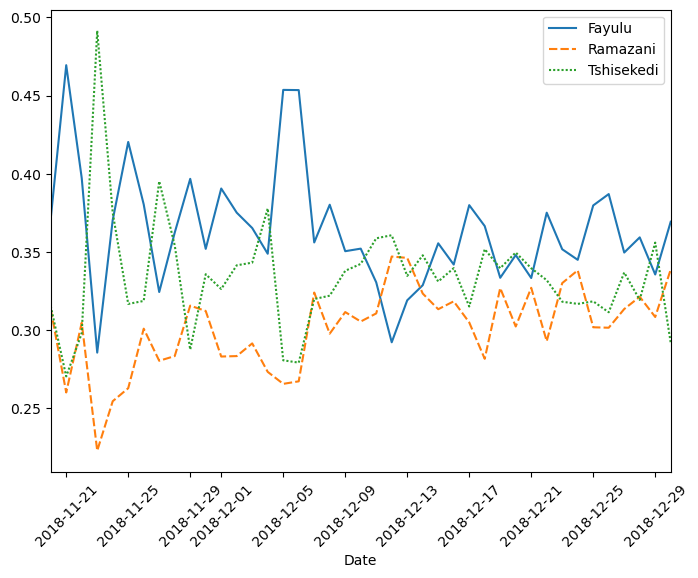

In [6]:
# Leaders popularity dynamics from VADER model

plt.figure(figsize=[8,6])
sns.lineplot(data = TSSW_VADER, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice TSSW', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_TSSW.pdf', bbox_inches = 'tight', pad_inches = .1);

In [7]:
# compute TSSW time series from BERT model
TSSW_BERT = compute_tssw_index(df, date_col="Date", leader_col="Leader", sentiment_col="Sentiment_BERT",
                             leaders=["Fayulu", "Ramazani", "Tshisekedi"],
                             start_date=start_date, end_date=end_date)

# quick info
print("TSSW shape:", TSSW_BERT.info())
TSSW_BERT.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fayulu      41 non-null     float64
 1   Ramazani    41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 1.3+ KB
TSSW shape: None


,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.312321,0.290353,0.397326
2018-11-21,0.306911,0.334688,0.358401
2018-11-22,0.280816,0.350324,0.368860
2018-11-23,0.334413,0.353856,0.311730
2018-11-24,0.293712,0.359663,0.346626


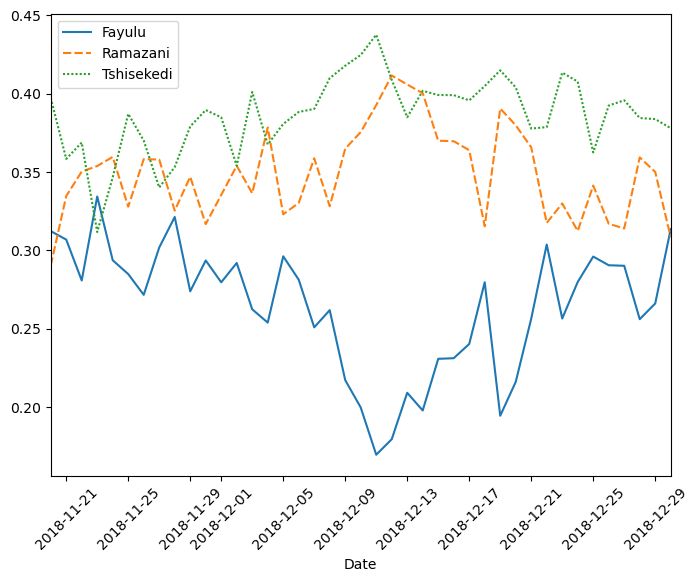

In [8]:
# Leaders popularity dynamics from BERT model

plt.figure(figsize=[8,6])
sns.lineplot(data = TSSW_BERT, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice TSSW', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_TSSW_BERT.pdf', bbox_inches = 'tight', pad_inches = .1);

### WG index

In [9]:
# --- Vectorized WG index computation ---
def compute_wg_index(
    df: pd.DataFrame,
    date_col: str = "Date",
    leader_col: str = "Leader",
    sentiment_col: str = "Sentiment",
    leaders: list | None = None,
    start_date: date | None = None,
    end_date: date | None = None,
) -> pd.DataFrame:
    """
    Compute daily WG index for each leader and return DataFrame:
      - index: sorted dates (datetime.date)
      - columns: leaders (strings)
    WG_t(a) = [ pos_t(a) / (pos_t(a) + neg_t(a)) ] * [ N_t(a) / total_N_t ]
    where total_N_t = sum_a N_t(a) and N_t(a)=pos+neg+neutral for leader a.
    Normalizes per date so the three leaders sum to 1. If no info on a date, returns equal shares.
    """
    df2 = df.copy()
    df2[date_col] = pd.to_datetime(df2[date_col]).dt.date

    if leaders is None:
        leaders = sorted(df2[leader_col].dropna().unique().tolist())

    # optional date window
    if start_date is not None:
        df2 = df2[df2[date_col] >= start_date]
    if end_date is not None:
        df2 = df2[df2[date_col] <= end_date]

    # daily cross-tab of counts (date x (leader, sentiment))
    ct = pd.crosstab(df2[date_col], [df2[leader_col], df2[sentiment_col]])

    # ensure all expected (leader, sentiment) columns exist
    sentiments = ["positive", "negative", "neutral"]
    all_cols = pd.MultiIndex.from_product([leaders, sentiments])
    ct = ct.reindex(columns=all_cols, fill_value=0).sort_index(axis=1)

    # get pos, neg, neutral as DataFrames with leader columns (no sentiment level)
    pos = ct.loc[:, pd.IndexSlice[:, "positive"]].copy()
    pos.columns = pos.columns.droplevel(1)
    neg = ct.loc[:, pd.IndexSlice[:, "negative"]].copy()
    neg.columns = neg.columns.droplevel(1)
    neu = ct.loc[:, pd.IndexSlice[:, "neutral"]].copy()
    neu.columns = neu.columns.droplevel(1)

    # term1: pos / (pos + neg)  (avoid division-by-zero -> NaN)
    pos_plus_neg = pos + neg
    term1 = pos.div(pos_plus_neg.replace({0: np.nan}))

    # N_a = pos + neg + neutral ; total_N = sum_a N_a
    N_a = pos + neg + neu
    total_N = N_a.sum(axis=1).replace({0: np.nan})  # avoid divide by zero

    # term2: N_a / total_N  (row-wise division)
    term2 = N_a.div(total_N, axis=0)

    # raw WG = term1 * term2
    wg_raw = term1 * term2

    # normalize per date so sum across leaders = 1
    wg_sum = wg_raw.sum(axis=1)
    wg_norm = wg_raw.div(wg_sum.replace({0: np.nan}), axis=0)

    # fallback: if a row is all NaN (e.g., no tweets), give equal shares
    equal_share = 1.0 / len(leaders)
    wg_norm = wg_norm.fillna(equal_share)

    # enforce column order and return
    wg_norm = wg_norm[leaders].sort_index()
    return wg_norm

In [10]:
# compute WG time series from VADER model
WG_VADER = compute_wg_index(
    df,
    date_col="Date",
    leader_col="Leader",
    sentiment_col="Sentiment_VADER",
    leaders=["Fayulu", "Ramazani", "Tshisekedi"],
    start_date=start_date,
    end_date=end_date,
)

# quick sanity checks
print("WG_dataset shape:", WG_VADER.info())
WG_VADER.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fayulu      41 non-null     float64
 1   Ramazani    41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 1.3+ KB
WG_dataset shape: None


,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.507739,0.333364,0.158897
2018-11-21,0.791796,0.110388,0.097816
2018-11-22,0.568808,0.233978,0.197215
2018-11-23,0.306847,0.144704,0.548449
2018-11-24,0.524853,0.145083,0.330063


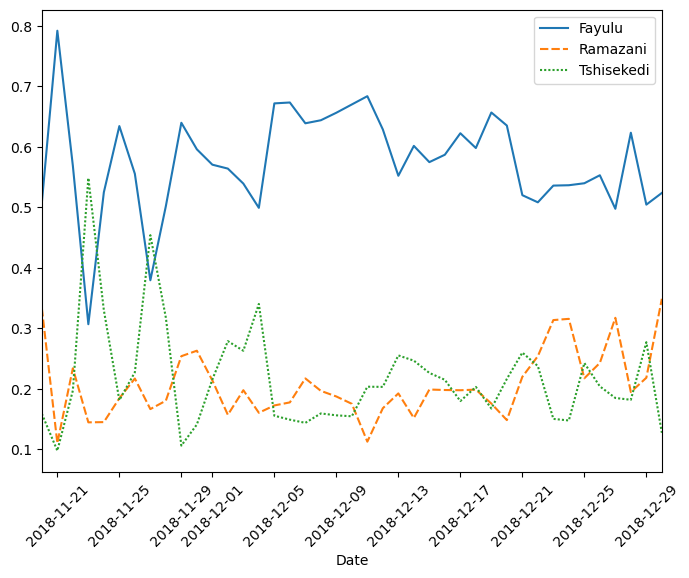

In [11]:
# Leaders popularity dynamics from VADER model

plt.figure(figsize=[8,6])
sns.lineplot(data = WG_VADER, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice WG', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_WG.pdf', bbox_inches = 'tight', pad_inches = .1);

In [12]:
# compute WG time series from BERT model
WG_BERT = compute_wg_index(
    df,
    date_col="Date",
    leader_col="Leader",
    sentiment_col="Sentiment_BERT",
    leaders=["Fayulu", "Ramazani", "Tshisekedi"],
    start_date=start_date,
    end_date=end_date,
)

# quick sanity checks
print("WG_dataset shape:", WG_BERT.info())
WG_BERT.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fayulu      41 non-null     float64
 1   Ramazani    41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 1.3+ KB
WG_dataset shape: None


,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.567009,0.241771,0.191220
2018-11-21,0.831775,0.090861,0.077364
2018-11-22,0.578744,0.227958,0.193298
2018-11-23,0.353373,0.160503,0.486124
2018-11-24,0.549073,0.148928,0.302000


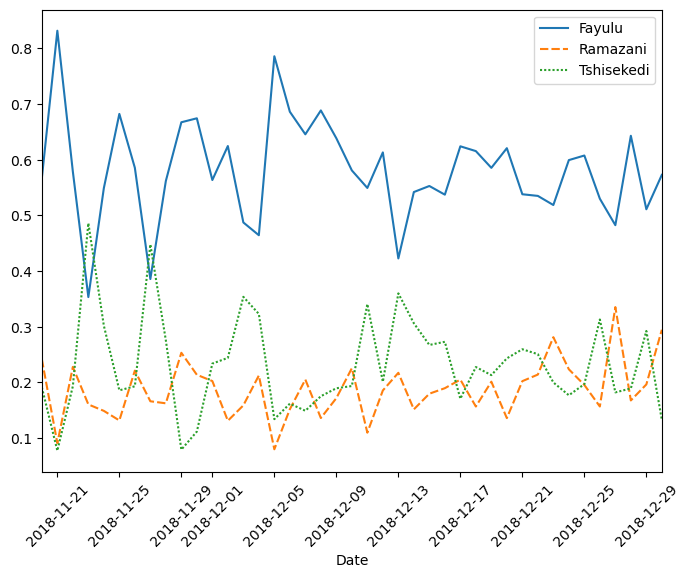

In [13]:
# Leaders popularity dynamics from BERT model

plt.figure(figsize=[8,6])
sns.lineplot(data = WG_BERT, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice WG', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_WG_BERT.pdf', bbox_inches = 'tight', pad_inches = .1);

### YHRM index

In [14]:
# --- Vectorized YHRM index computation ---
def compute_yhrm_index(
    df: pd.DataFrame,
    date_col: str = "Date",
    leader_col: str = "Leader",
    sentiment_col: str = "Sentiment",
    leaders: list | None = None,
    start_date: date | None = None,
    end_date: date | None = None,
) -> pd.DataFrame:
    """
    Compute daily YHRM index for each leader and return DataFrame:
      - index: sorted dates (datetime.date)
      - columns: leaders (strings)

    YHRM_t(a) = pos_t(a) / neg_{t+1}(a).
    The last date will have NaNs for neg_{t+1} (so YHRM is NaN); rows with no data fall back to equal shares.
    """
    df2 = df.copy()
    df2[date_col] = pd.to_datetime(df2[date_col]).dt.date

    if leaders is None:
        leaders = sorted(df2[leader_col].dropna().unique().tolist())

    # optional date window
    if start_date is not None:
        df2 = df2[df2[date_col] >= start_date]
    if end_date is not None:
        df2 = df2[df2[date_col] <= end_date]

    # daily cross-tab of counts (date x (leader, sentiment))
    ct = pd.crosstab(df2[date_col], [df2[leader_col], df2[sentiment_col]])

    # ensure all expected (leader, sentiment) columns exist
    sentiments = ["positive", "negative", "neutral"]
    all_cols = pd.MultiIndex.from_product([leaders, sentiments])
    ct = ct.reindex(columns=all_cols, fill_value=0).sort_index(axis=1)

    # extract pos and neg DataFrames with simple columns = leaders
    pos = ct.loc[:, pd.IndexSlice[:, "positive"]].copy()
    pos.columns = pos.columns.droplevel(1)
    neg = ct.loc[:, pd.IndexSlice[:, "negative"]].copy()
    neg.columns = neg.columns.droplevel(1)

    # reindex to full date range between provided bounds if requested (keeps continuity & allows shift)
    if start_date is not None and end_date is not None:
        full_dates = pd.date_range(start=start_date, end=end_date, freq="D").date
        pos = pos.reindex(full_dates, fill_value=0)
        neg = neg.reindex(full_dates, fill_value=0)
    else:
        # ensure sorted index
        pos = pos.sort_index()
        neg = neg.sort_index()

    # compute neg_{t+1} aligned with pos_t: shift neg backwards (i.e. for date t use neg at t+1)
    neg_next = neg.shift(-1)

    # avoid division by zero -> replace zeros with NaN so division produces NaN
    neg_next_safe = neg_next.replace({0: np.nan})

    # raw YHRM: pos_t / neg_{t+1}
    yhrm_raw = pos.div(neg_next_safe)

    # row-wise normalization so each date sums to 1 (where at least one non-NaN exists)
    row_sum = yhrm_raw.sum(axis=1)
    yhrm_norm = yhrm_raw.div(row_sum.replace({0: np.nan}), axis=0)

    # fallback: if a row is all NaN (e.g. no tweets or neg_next all zero), use equal shares
    equal_share = 1.0 / len(leaders)
    yhrm_norm = yhrm_norm.fillna(equal_share)

    # enforce column order and return (columns as simple leader names)
    yhrm_norm = yhrm_norm[leaders].sort_index()
    return yhrm_norm

In [15]:
# compute YHRM time series from VADER model
YHRM_VADER = compute_yhrm_index(
    df,
    date_col="Date",
    leader_col="Leader",
    sentiment_col="Sentiment_VADER",
    leaders=["Fayulu", "Ramazani", "Tshisekedi"],
    start_date=start_date,
    end_date=end_date-timedelta(days=1),
)

# Quick check
print("YHRM_dataset shape:", YHRM_VADER.info())
YHRM_VADER.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fayulu      41 non-null     float64
 1   Ramazani    41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 1.3+ KB
YHRM_dataset shape: None


,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.222873,0.407145,0.369981
2018-11-21,0.591054,0.189379,0.219568
2018-11-22,0.435742,0.301603,0.262656
2018-11-23,0.141484,0.170031,0.688485
2018-11-24,0.221461,0.108527,0.670012


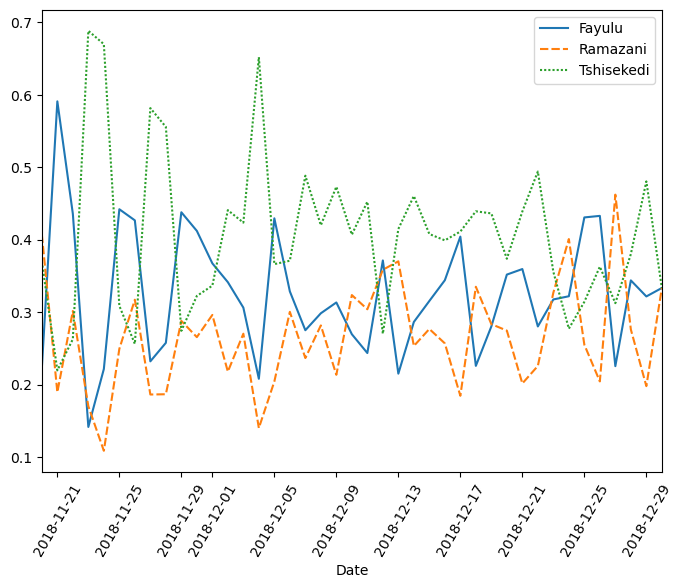

In [16]:
# Leaders popularity dynamics from VADER model

plt.figure(figsize=[8,6])
sns.lineplot(data = YHRM_VADER, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice HRM', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=60)
plt.savefig('popularity_dynamics_of_leaders_HRM.pdf', bbox_inches = 'tight', pad_inches = .1);

In [17]:
# compute YHRM time series from BERT model
YHRM_BERT = compute_yhrm_index(
    df,
    date_col="Date",
    leader_col="Leader",
    sentiment_col="Sentiment_BERT",
    leaders=["Fayulu", "Ramazani", "Tshisekedi"],
    start_date=start_date,
    end_date=end_date-timedelta(days=1),
)

# Quick check
print("YHRM_dataset shape:", YHRM_BERT.info())
YHRM_BERT.head()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fayulu      41 non-null     float64
 1   Ramazani    41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 1.3+ KB
YHRM_dataset shape: None


,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.237913,0.331665,0.430423
2018-11-21,0.622083,0.198442,0.179475
2018-11-22,0.525006,0.350974,0.124019
2018-11-23,0.200674,0.296164,0.503162
2018-11-24,0.279860,0.148426,0.571714


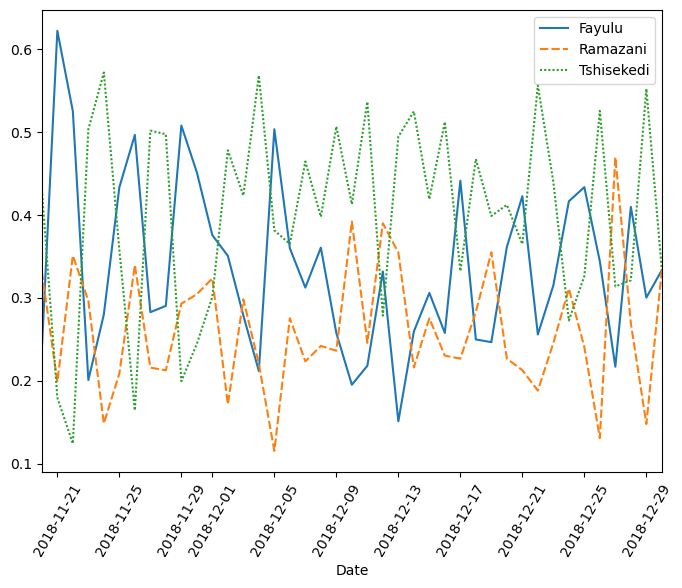

In [18]:
# Leaders popularity dynamics from BERT model

plt.figure(figsize=[8,6])
sns.lineplot(data = YHRM_BERT, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice HRM', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=60)
plt.savefig('popularity_dynamics_of_leaders_HRM_BERT.pdf', bbox_inches = 'tight', pad_inches = .1);

## Penalized indices

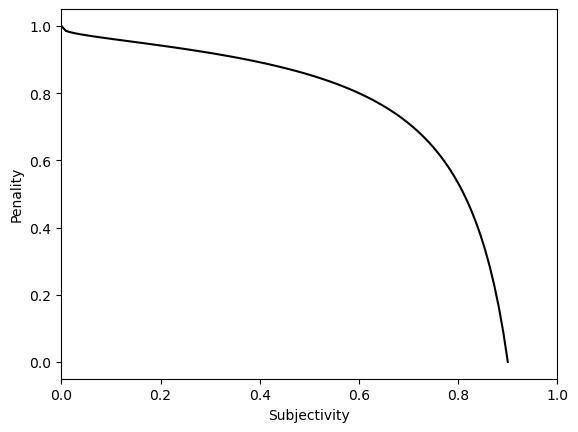

In [19]:
# Simulation of the penalization function

eps = 1e-06
x_values = np.linspace(start=0, stop=.9, num=100)
y_values = 1/np.log(x_values + eps)
y_values_scaled = (y_values - y_values.min())/(y_values.max() - y_values.min())
plt.plot(x_values, y_values_scaled, color = 'black')
plt.xlim(0,1)
plt.xlabel('Subjectivity')
plt.ylabel('Penality')
plt.savefig('penalization_function.pdf', bbox_inches = 'tight', pad_inches = .1);

In [20]:
# ensure df["Date"] is date and baseline indices exist
df["Date"] = pd.to_datetime(df["Date"]).dt.date

# align baseline indices to a common index (dates)
LEADERS = list(df.Leader.unique())

vader_indices = TSSW_VADER.index.union(WG_VADER.index).union(YHRM_VADER.index).sort_values()
tssw_vader = TSSW_VADER.reindex(vader_indices).fillna(0.0)[LEADERS]
wg_vader = WG_VADER.reindex(vader_indices).fillna(0.0)[LEADERS]
yhrm_vader = YHRM_VADER.reindex(vader_indices).fillna(0.0)[LEADERS]

bert_indices = TSSW_BERT.index.union(WG_BERT.index).union(YHRM_BERT.index).sort_values()
tssw_bert = TSSW_BERT.reindex(bert_indices).fillna(0.0)[LEADERS]
wg_bert = WG_BERT.reindex(bert_indices).fillna(0.0)[LEADERS]
yhrm_bert = YHRM_BERT.reindex(bert_indices).fillna(0.0)[LEADERS]

In [21]:
# compute daily mean subjectivity per leader, aligned to common_index
subjectivity_mean = (
    df
    .pivot_table(values="Subjectivity", index=df["Date"], columns="Leader", aggfunc="mean")
    .reindex(vader_indices)
)

# ensure all leader columns present
for leader in LEADERS:
    if leader not in subjectivity_mean.columns:
        subjectivity_mean[leader] = 0.0
subjectivity_mean = subjectivity_mean[LEADERS].fillna(0.0)

# raw penalty: 1 / log(subjectivity) with clipping (avoid log(0))
eps = 1e-6
subj_clipped = subjectivity_mean.clip(lower=eps, upper=0.999)
raw = 1.0 / np.log(subj_clipped)   # DataFrame, shape (n_dates, n_leaders)

In [22]:
# Penalization factor

from sklearn.preprocessing import MinMaxScaler

epsilon = 1e-4      # this is the smoothing Laplace parameter

subjectivity_mean = df.pivot_table(values='Subjectivity', index='Date', columns='Leader', aggfunc='mean')
penality = MinMaxScaler(feature_range=(0,1)).fit_transform(1/(np.log(subjectivity_mean + epsilon)))
penality = pd.DataFrame(penality, index=subjectivity_mean.index, columns=subjectivity_mean.columns)
penality

Leader,Fayulu,Ramazani,Tshisekedi
Date,,,
2018-11-20,0.377353,0.490792,0.000000
2018-11-21,0.462050,0.724207,0.221593
2018-11-22,0.579092,0.444664,0.610212
2018-11-23,0.220896,0.077366,0.107269
2018-11-24,0.000000,0.155987,0.106092
2018-11-25,0.401094,0.471451,0.459733
2018-11-26,0.457595,0.538140,0.545142
2018-11-27,0.255643,0.144250,0.311547
2018-11-28,0.384185,0.082803,0.619622


In [23]:
# Function to apply penalization elementwise and renormalize per date (so each row sums to 1)

def apply_penality_and_renormalize(index_df: pd.DataFrame, penality_df: pd.DataFrame) -> pd.DataFrame:
    # align indices and columns
    idx = index_df.index
    idx_df = index_df.reindex(idx).fillna(0.0)[LEADERS]
    pen_df = penality_df.reindex(idx).fillna(1.0/len(LEADERS))[LEADERS]

    penalized_raw = idx_df * pen_df
    row_sum = penalized_raw.sum(axis=1)
    penalized_norm = penalized_raw.div(row_sum.replace({0: np.nan}), axis=0)
    # fallback to equal shares where division yields NaN or row_sum==0
    penalized_norm = penalized_norm.fillna(1.0 / len(LEADERS))
    return penalized_norm

In [24]:
# Applying the penalization function to popularity indices

P_TSSW_VADER = apply_penality_and_renormalize(tssw_vader, penality)
P_WG_VADER = apply_penality_and_renormalize(wg_vader, penality)
P_YHRM_VADER = apply_penality_and_renormalize(yhrm_vader, penality)

P_TSSW_BERT = apply_penality_and_renormalize(tssw_bert, penality)
P_WG_BERT = apply_penality_and_renormalize(wg_bert, penality)
P_YHRM_BERT = apply_penality_and_renormalize(yhrm_bert, penality)

# Quick info
print("penality shape:", penality.shape)
print("Baseline TSSW from VADER: ", P_TSSW_VADER.info())
print("Baseline WG from VADER: ", P_WG_VADER.info())
print("Baseline YHRM from VADER: ", P_YHRM_VADER.info())
print("Penalized TSSW from BERT: ", P_TSSW_BERT.info())
print("Penalized TSSW from BERT: ", P_WG_BERT.info())
print("Penalized TSSW from BERT: ", P_YHRM_BERT.info())

penality shape: (41, 3)
<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ramazani    41 non-null     float64
 1   Fayulu      41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 2.3+ KB
Baseline TSSW from VADER:  None
<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Ramazani    41 non-null     float64
 1   Fayulu      41 non-null     float64
 2   Tshisekedi  41 non-null     float64
dtypes: float64(3)
memory usage: 2.3+ KB
Baseline WG from VADER:  None
<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 2018-11-20 to 2018-12-30
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  ----- 

### P-TSSW index

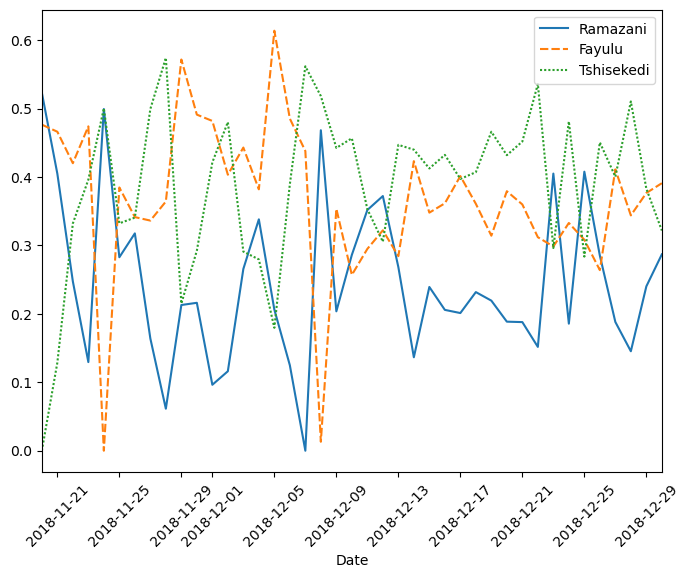

In [25]:
# Leaders popularity dynamics from VADER model

plt.figure(figsize=[8,6])
sns.lineplot(data = P_TSSW_VADER, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice TSSW', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_TSSW_P.pdf', bbox_inches = 'tight', pad_inches = .1);

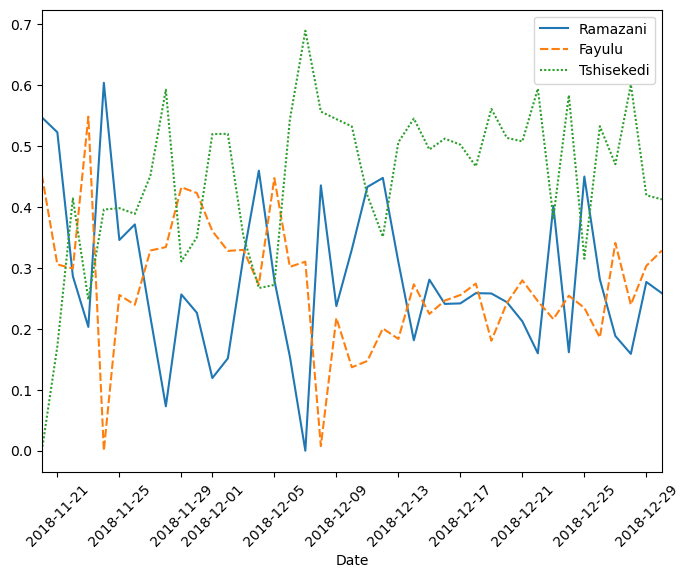

In [26]:
# Leaders popularity dynamics from BERT model

plt.figure(figsize=[8,6])
sns.lineplot(data = P_TSSW_BERT, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice TSSW', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_TSSW_P_BERT.pdf', bbox_inches = 'tight', pad_inches = .1);

### P-WG index

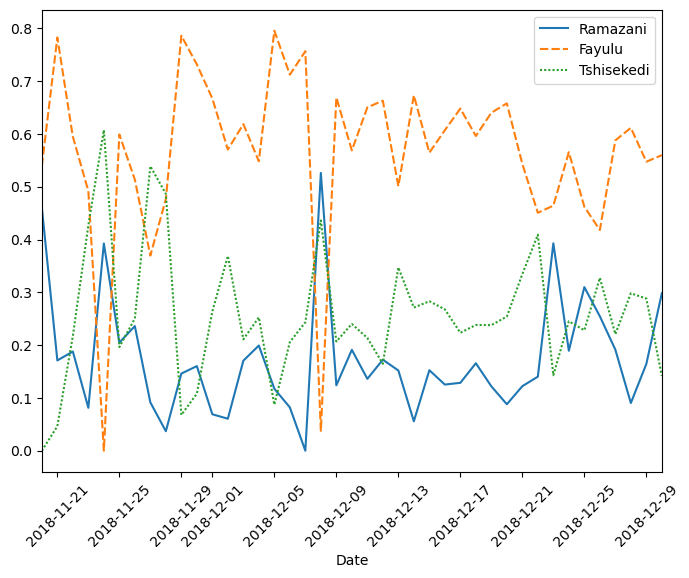

In [27]:
# Leaders popularity dynamics from VADER model

plt.figure(figsize=[8,6])
sns.lineplot(data = P_WG_VADER, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice WG', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_WG_P.pdf', bbox_inches = 'tight', pad_inches = .1);

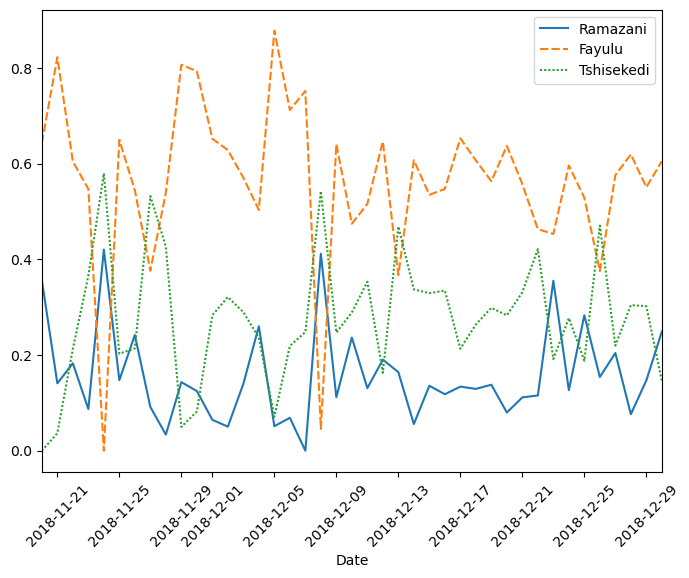

In [28]:
# Leaders popularity dynamics from BERT model

plt.figure(figsize=[8,6])
sns.lineplot(data = P_WG_BERT, palette = 'tab10')
#plt.title('Dynamique de popularité des leaders \nIndice WG', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=45)
plt.savefig('popularity_dynamics_of_leaders_WG_P.pdf', bbox_inches = 'tight', pad_inches = .1);

### P-YHRM index

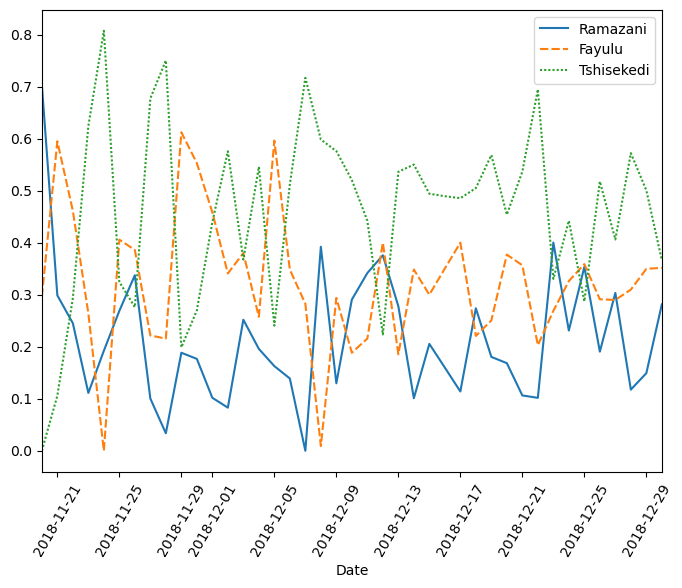

In [29]:
# Leaders popularity dynamics from VADER model

plt.figure(figsize=[8,6])
sns.lineplot(data = P_YHRM_VADER, palette = 'tab10')
#plt.title('Dynamique de popularite des leaders \nIndice HRM', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=60)
plt.savefig('popularity_dynamics_of_leaders_HRM_P.pdf', bbox_inches = 'tight', pad_inches = .1);

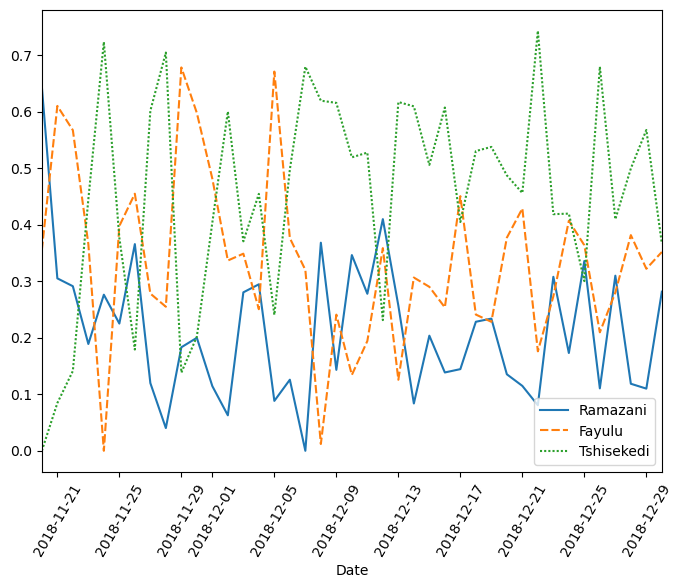

In [30]:
# Leaders popularity dynamics from BERT model

plt.figure(figsize=[8,6])
sns.lineplot(data = P_YHRM_BERT, palette = 'tab10')
#plt.title('Dynamique de popularite des leaders \nIndice HRM', loc='left')
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.xticks(rotation=60)
plt.savefig('popularity_dynamics_of_leaders_HRM_P.pdf', bbox_inches = 'tight', pad_inches = .1);

## Merging all data

In [31]:
# List all DataFrames with their metadata

dataframes_info = [
    (TSSW_VADER, 'TSSW', 'VADER', 'baseline'),
    (WG_VADER, 'WG', 'VADER', 'baseline'),
    (YHRM_VADER, 'YHRM', 'VADER', 'baseline'),
    (TSSW_BERT, 'TSSW', 'BERT', 'baseline'),
    (WG_BERT, 'WG', 'BERT', 'baseline'),
    (YHRM_BERT, 'YHRM', 'BERT', 'baseline'),
    (P_TSSW_VADER, 'TSSW', 'VADER', 'penalized'),
    (P_WG_VADER, 'WG', 'VADER', 'penalized'),
    (P_YHRM_VADER, 'YHRM', 'VADER', 'penalized'),
    (P_TSSW_BERT, 'TSSW', 'BERT', 'penalized'),
    (P_WG_BERT, 'WG', 'BERT', 'penalized'),
    (P_YHRM_BERT, 'YHRM', 'BERT', 'penalized')
]

In [32]:
# Create an empty list to store all the transformed DataFrames
all_dfs = []

# Process each DataFrame
for df, popularity_index, approach, variant in dataframes_info:
    # Reset index to get date as a column
    temp_df = df.reset_index()
    temp_df = temp_df.rename(columns={'index': 'Date'})
    
    # Melt the DataFrame to convert leaders from columns to rows
    melted_df = pd.melt(temp_df, 
                        id_vars=['Date'], 
                        value_vars=['Fayulu', 'Ramazani', 'Tshisekedi'],
                        var_name='leader',
                        value_name='popularity_value')
    
    # Add the metadata columns
    melted_df['popularity_index'] = popularity_index
    melted_df['approach'] = approach
    melted_df['variant'] = variant
    
    # Reorder columns
    melted_df = melted_df[['Date', 'leader', 'popularity_index', 'approach', 'variant', 'popularity_value']]
    
    all_dfs.append(melted_df)

In [33]:
# Combine all DataFrames
combined_df = pd.concat(all_dfs, ignore_index=True)

# Ensure date is in datetime format and sort by date in ascending order
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df.sort_values('Date', inplace=True)

# Set date as index
combined_df.set_index('Date', inplace=True)
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1476 entries, 2018-11-20 to 2018-12-30
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   leader            1476 non-null   object 
 1   popularity_index  1476 non-null   object 
 2   approach          1476 non-null   object 
 3   variant           1476 non-null   object 
 4   popularity_value  1476 non-null   float64
dtypes: float64(1), object(4)
memory usage: 69.2+ KB


### Moving Average

Saved: plots/moving_avg_tssw_vader.pdf


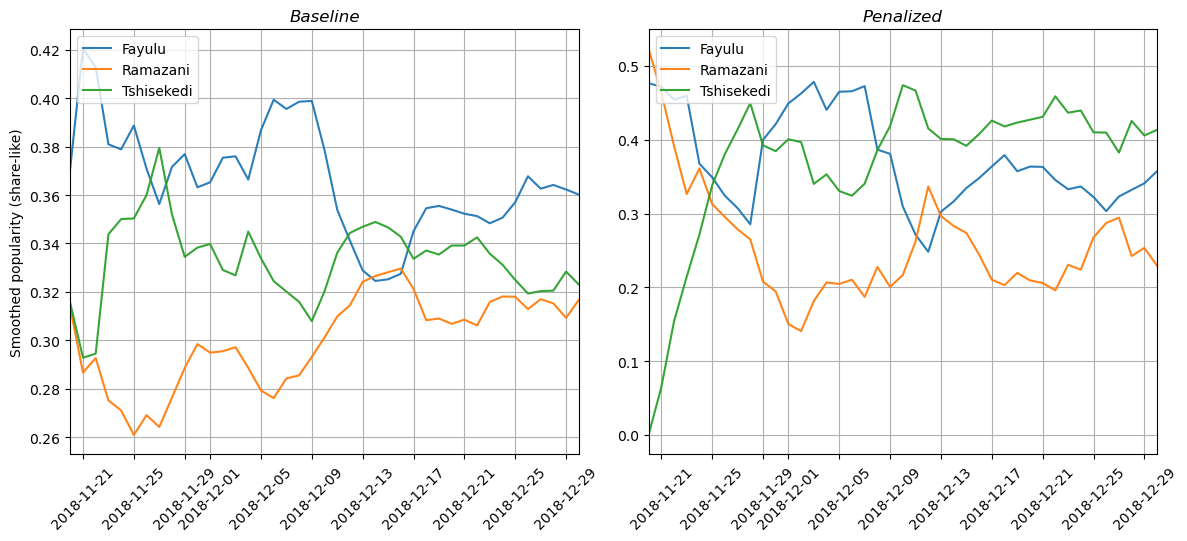

Saved: plots/moving_avg_tssw_bert.pdf


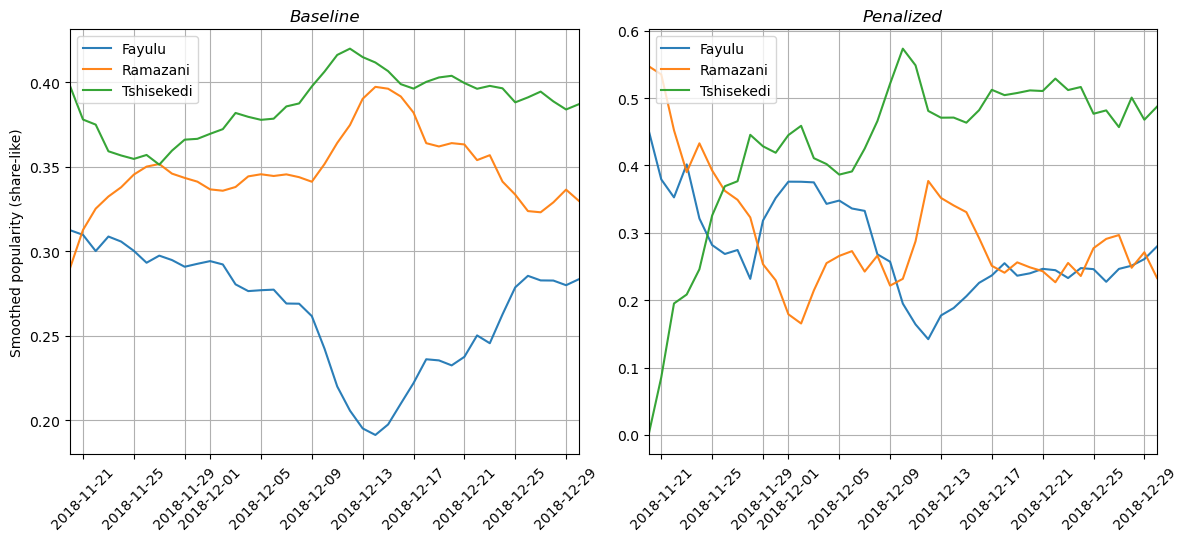

Saved: plots/moving_avg_wg_vader.pdf


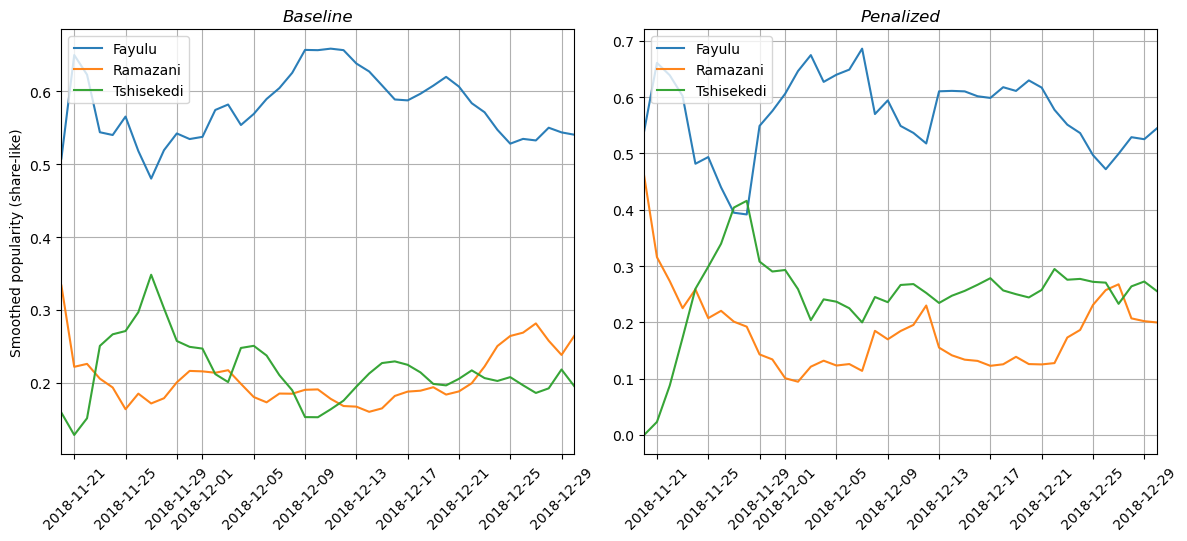

Saved: plots/moving_avg_wg_bert.pdf


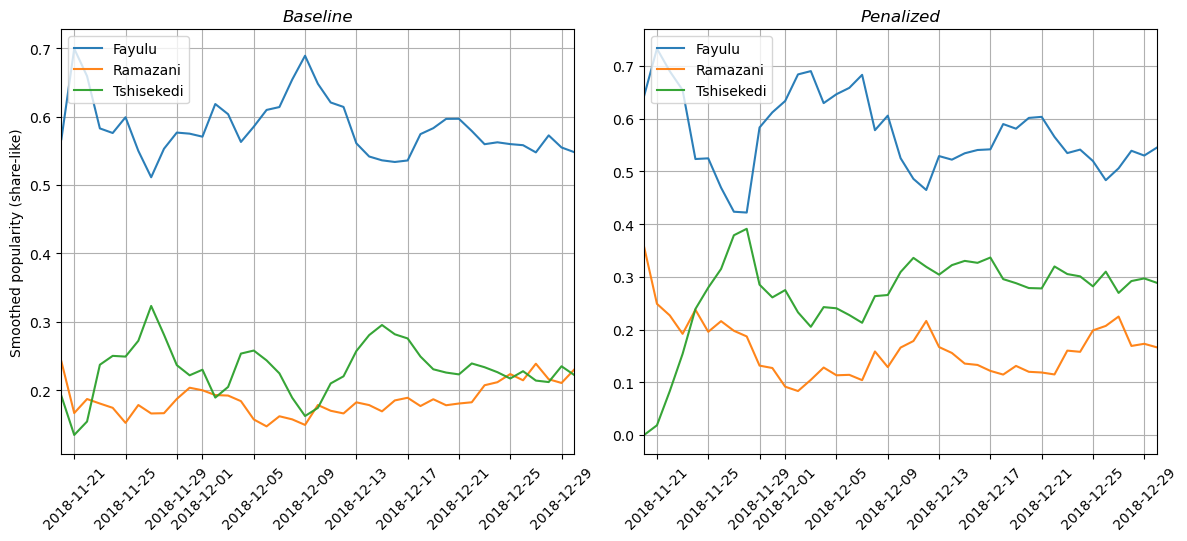

Saved: plots/moving_avg_yhrm_vader.pdf


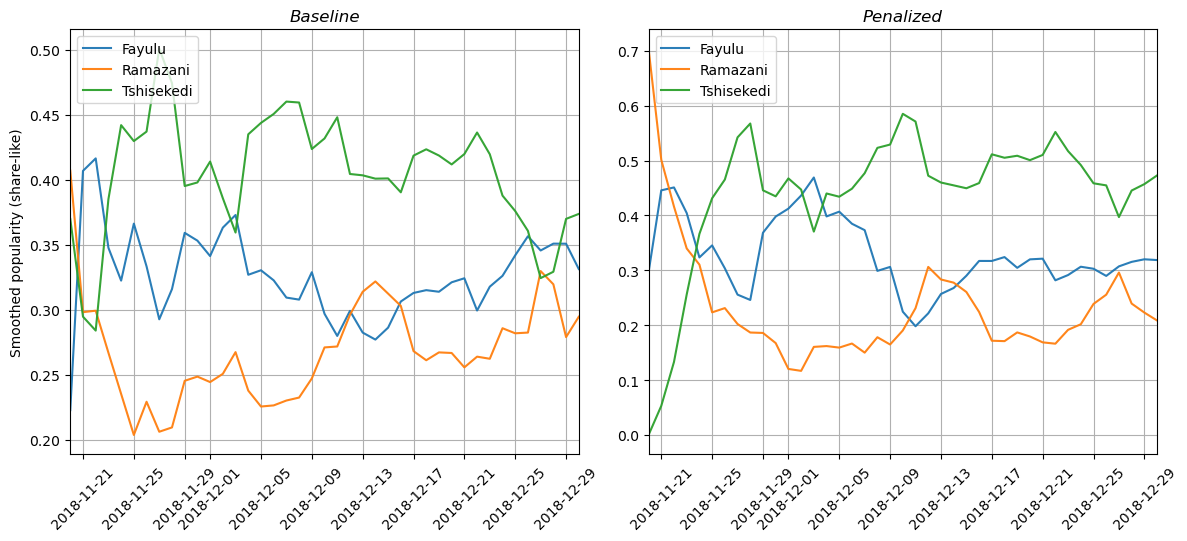

Saved: plots/moving_avg_yhrm_bert.pdf


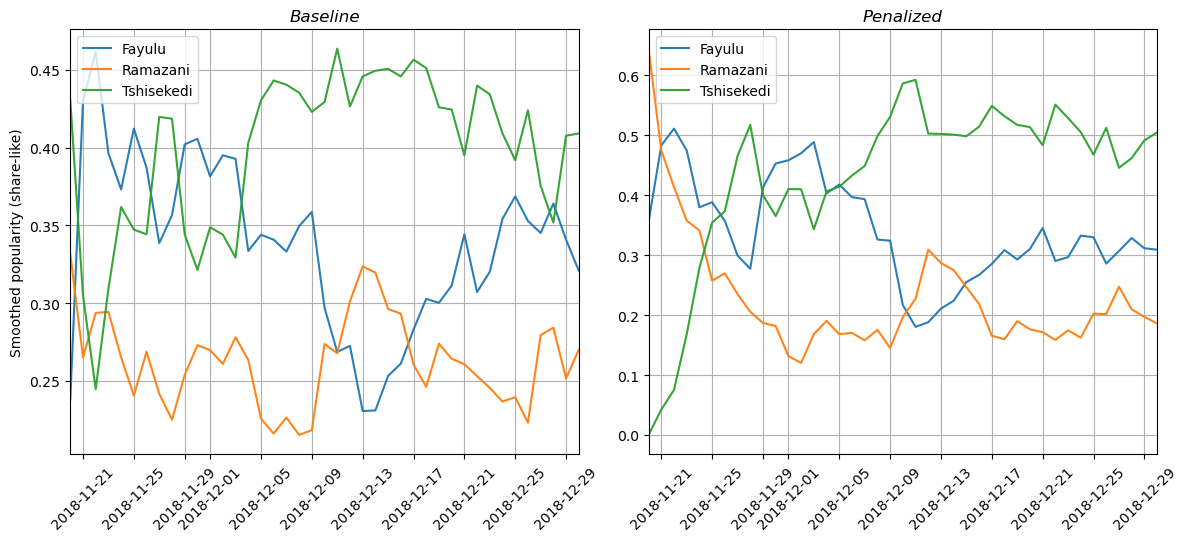

In [ ]:
# Moving-average smoothing + plotting for all popularity series
# Inputs required: combined_df (DatetimeIndex), columns: ['leader','popularity_index','approach','variant','popularity_value']
# Output: 6 figures (one per (index,approach)), each with 2 subplots (baseline vs penalized)
# Usage example: run with window_days = 3 or 7

import os
from matplotlib.dates import DateFormatter

# Template styles (colors & line types)
sns.set(style='whitegrid')
LEADER_STYLES = {
    'Fayulu':   {'color': '#1f77b4', 'label': 'Fayulu'},
    'Ramazani': {'color': '#ff7f0e', 'label': 'Ramazani'},
    'Tshisekedi':{'color': '#2ca02c', 'label': 'Tshisekedi'}
}

def plot_moving_averages(combined_df,
                         window_days=3,
                         leaders=None,
                         indices=None,
                         approaches=None,
                         variants=('baseline','penalized'),
                         save_dir='plots',
                         min_periods=1):
    # Defaults
    if leaders is None:
        leaders = sorted(combined_df['leader'].unique().tolist())
    if indices is None:
        indices = ['TSSW','WG','YHRM']
    if approaches is None:
        approaches = ['VADER','BERT']
    os.makedirs(save_dir, exist_ok=True)

    # canonical full daily index
    full_dates = pd.date_range(start=combined_df.index.min().date(),
                               end=combined_df.index.max().date(), freq='D')

    # iterate combinations (index x approach) -> produce one figure (2 subplots: baseline vs penalized)
    for idx in indices:
        for appr in approaches:
            fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
            #fig.suptitle(f"{idx} — {appr}  (moving avg window = {window_days} days)", fontsize=14, fontweight='bold')

            for ax, variant in zip(axes, variants):
                # filter the subset
                mask = (
                    (combined_df['popularity_index'] == idx) &
                    (combined_df['approach'] == appr) &
                    (combined_df['variant'] == variant)
                )
                sub = combined_df.loc[mask].copy()
                if sub.empty:
                    ax.text(0.5, 0.5, 'No data for this combination', ha='center', va='center')
                    ax.set_title(f"{variant.capitalize()} (no data)", style='italic')
                    ax.set_xlabel('')
                    ax.set_ylabel('')
                    continue

                # ensure Date column and pivot to leaders
                tmp = sub.reset_index().rename(columns={'index':'Date'})
                pivot = tmp.pivot(index='Date', columns='leader', values='popularity_value')

                # reindex to full calendar, keep NaNs where missing
                pivot = pivot.reindex(full_dates)

                # compute rolling mean (window_days)
                ma = pivot.rolling(window=window_days, min_periods=min_periods).mean()
                
                # plot each leader using the template styles
                for leader in leaders:
                    if leader not in ma.columns:
                        continue
                    sty = LEADER_STYLES.get(leader, {'color':None, 'linewidth':2.2})
                    ax.plot(ma.index, ma[leader],
                            color=sty['color'],
                            label=sty.get('label', leader),
                            alpha=0.95)

                ax.set_title(variant.capitalize(), style='italic')
                ax.set_xlabel('')
                ax.xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
                ax.tick_params(axis='x', rotation=45)
                if ax is axes[0]:
                    ax.set_ylabel('Smoothed popularity (share-like)')
                ax.grid(True)
                ax.set_xlim(full_dates.min(), full_dates.max())
                ax.legend(title='', loc='upper left', frameon=True)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            # save
            fname = f"{save_dir}/moving_avg_{idx.lower()}_{appr.lower()}.pdf"
            fig.savefig(fname, bbox_inches='tight', dpi=200)
            print(f"Saved: {fname}")
            plt.show()

# choose the window (3, 5, 7, etc.)
plot_moving_averages(combined_df, window_days=5)

In [35]:
# Export to CSV
csv_filename = "popularity_data.csv"
combined_df.to_csv(csv_filename)
print(f"\nDataFrame successfully exported to: {csv_filename}")


DataFrame successfully exported to: popularity_data.csv
